# Dal camminare al calcio: analisi del passo

## Introduzione
In questo notebook esploreremo le differenze tra camminare scalzi e con le scarpe da calcio. Il notebook mira a scovare ed analizzare le differenze nella dinamicità della camminata. 

Verranno utilizzati dati inerziali raccolti attraverso un accelerometro e un giroscopio. I dati raccolti risulteranno rumorosi per cui sarà necessaria una fase di filtraggio. 

I dati sono stati raccolti da 10 soggetti aventi statura e peso corporeo molto diversi tra loro. Le rilevazioni sono state fatte in due blocchi differenti. Entrambi i gruppi hanno camminato in linea retta su una superficie piana e rigida.

Verranno estratte delle caratteristiche da ogni segnale, per poi creare un grafico. In tale grafico di dovrebbe osservare come, i soggetti aventi caratteristiche fisiche simili, tendano a raggrupparsi in diverse zone del piano cartesiano. Inoltre si dovrà vedere una leggera divisione tra le misurazioni effettuate senza scarpe e quelle con le scarpe.

### Autore
Marco Mammoliti     
Email: S5564736@studenti.unige.it, mammolo103@gmail.com

![Alt des: This image shows the direction of the axis](../dati/im.png)

## Metodi

Durante la fase di filtraggio e analisi, il segnale sarà elaborato tramite diverse funzioni

```pd.read_csv```  
È un metodo che permette la lettura dei dati da file csv. Ritorna una struttura dati avente etichette per ogni colonna presente nel file csv.

```gaussian_filter() ```   
Permette di applicare un filtro gaussiano tramite convoluzione. Ritorna un array esattamente come quello in input ma con i valori filtrati.

```np.fft.fft()```     
È una funzione che calcola la Trasformata di Fourier discreta del segnale in input. Ritorna lo spettro delle frequenze del segnale.

```np.fft.fftfreq()```     
Questa funzione calcola la Trasformata di Fourier discreta delle frequenze campionate. Il valore di ritorno è un array contenente tutte le frequeenze che possono apparire nel segnale.


## Esperimento
Come detto all'inizio, sono state effettuate rilevazioni su 10 soggetti diversi per un totale di 20 misurazioni.
Gli esperimenti sono stati svolti in due giorni differenti. Tutti i soggetti presi in esame hanno camminato in linea retta su un pavimento di piastrelle.

### Ipotesi:   
Dato che, le scarpe da calcio presentano i tacchetti, si attendono delle differenze significative nei dati. I tacchetti, oltre ad essere rigidi, sono presenti nella parte più esterna della pianta e non in modo uniforme.       
Le differenze sono attese, per l'accelerometro principalmente lungo l'asse verticale(y) e l'asse orizzontale(x), mentre per il giroscopio lungo l'asse orizzontale(z) che misura le rotazioni esterne/interne.  
Infatti camminare con le scarpe da calcio risulta un movimento brusco, robotico e innaturale, per questo sono attese evidenti differenze.

## Uploading dei dati
Di seguito verranno importati i __dati__ raccolti durante gli esperimenti.      
Saranno organizzati in __due matrici 2 x 10__. Le due matrici conterranno __rispettivamente__ i dati dell'__accelerometro__ e del __giroscopio__. Nelle matrici vi sono due colonne, ciò permette di organizzare i dati raccolti __senza scarpe__(sotto l'__indice 0__) e quelli __con le scarpe__ da calcio (sotto l'__indice 1__).

In [85]:
import pandas as pd
import matplotlib.pyplot as plt


nomi = "stelli", "deprati", "fazio", "foreman", "macchiavello", "massoni", "medica", "paladini", "tassara", "zanone"
# qui si crea la struttura dati
# sara formata da due matrici 2x10 
size, size2 = 2, 10

Accelerometro = [[0 for _ in range(size2)] for _ in range(size)]
Giroscopio = [[0 for _ in range(size2)] for _ in range(size)]

for i in range(size2):
    string = '../dati/scalzi/'+ nomi[i] + '/AccelerometerUncalibrated.csv'
    Accelerometro[0][i] = pd.read_csv(string)
    string = '../dati/scalzi/'+ nomi[i] + '/GyroscopeUncalibrated.csv'
    Giroscopio[0][i] = pd.read_csv(string)

    string = '../dati/scarpe/'+ nomi[i] + '/AccelerometerUncalibrated.csv'
    Accelerometro[1][i] = pd.read_csv(string)
    string = '../dati/scarpe/'+ nomi[i] + '/GyroscopeUncalibrated.csv'
    Giroscopio[1][i] = pd.read_csv(string)
    



Qui di seguito verranno effettuati dei tagli. Questo permette di mantenere solamente la parte significativa dei dati raccolti.

In [86]:
### Taglio dei dati
##### tagli dei dati scalzi              ##### con le scarpe

# stelli da 730 a 1500                   ---- da 500 a 1500
# deprati da 1000 a 1500                 ---- da 750 a 1300
# fazio da 680 a 2080                    ---- da 500 a 1850
# foreman da 1200 a 2400                 ---- da 480 a 1850
# macchiavello da 500 a 1000             ---- da 550 a 1050
# massoni da 750 a 2250                  ---- da 980 a 2400
# medica da 1200 a 2400                  ---- da 1000 a 2100
# paladini da 1200 a 2400                ---- da 550 a 1700
# tassara da 1550 a 2400                  ---- da 980 a 2250
# zanone da 980 a 2200                   ---- da 1180 a 2400

Accelerometro[0][0] = Accelerometro[0][0][730:1500]
Accelerometro[0][1] = Accelerometro[0][1][1000:1500]
Accelerometro[0][2] = Accelerometro[0][2][680:2080]
Accelerometro[0][3] = Accelerometro[0][3][1200:2400]
Accelerometro[0][4] = Accelerometro[0][4][500:1000]
Accelerometro[0][5] = Accelerometro[0][5][750:2250]
Accelerometro[0][6] = Accelerometro[0][6][1200:2400]
Accelerometro[0][7] = Accelerometro[0][7][1200:2400]
Accelerometro[0][8] = Accelerometro[0][8][1550:2400]
Accelerometro[0][9] = Accelerometro[0][9][980:2200]

Accelerometro[1][0] = Accelerometro[1][0][500:1500]
Accelerometro[1][1] = Accelerometro[1][1][750:1300]
Accelerometro[1][2] = Accelerometro[1][2][500:1850]
Accelerometro[1][3] = Accelerometro[1][3][480:1850]
Accelerometro[1][4] = Accelerometro[1][4][550:1050]
Accelerometro[1][5] = Accelerometro[1][5][980:2400]
Accelerometro[1][6] = Accelerometro[1][6][1000:2100]
Accelerometro[1][7] = Accelerometro[1][7][550:1700]
Accelerometro[1][8] = Accelerometro[1][8][980:2250]
Accelerometro[1][9] = Accelerometro[1][9][1180:2400]

Giroscopio[0][0] = Giroscopio[0][0][730:1500]
Giroscopio[0][1] = Giroscopio[0][1][1000:1500]
Giroscopio[0][2] = Giroscopio[0][2][680:2080]
Giroscopio[0][3] = Giroscopio[0][3][1200:2400]
Giroscopio[0][4] = Giroscopio[0][4][500:1000]
Giroscopio[0][5] = Giroscopio[0][5][750:2250]
Giroscopio[0][6] = Giroscopio[0][6][1200:2400]
Giroscopio[0][7] = Giroscopio[0][7][1200:2400]
Giroscopio[0][8] = Giroscopio[0][8][1550:2400]
Giroscopio[0][9] = Giroscopio[0][9][980:2200]

Giroscopio[1][0] = Giroscopio[1][0][500:1500]
Giroscopio[1][1] = Giroscopio[1][1][750:1300]
Giroscopio[1][2] = Giroscopio[1][2][500:1850]
Giroscopio[1][3] = Giroscopio[1][3][480:1850]
Giroscopio[1][4] = Giroscopio[1][4][550:1050]
Giroscopio[1][5] = Giroscopio[1][5][980:2400]
Giroscopio[1][6] = Giroscopio[1][6][1000:2100]
Giroscopio[1][7] = Giroscopio[1][7][550:1700]
Giroscopio[1][8] = Giroscopio[1][8][980:2250]
Giroscopio[1][9] = Giroscopio[1][9][1180:2400]

## Una prima occhiata ai dati
### Prima stampa (dati grezzi)

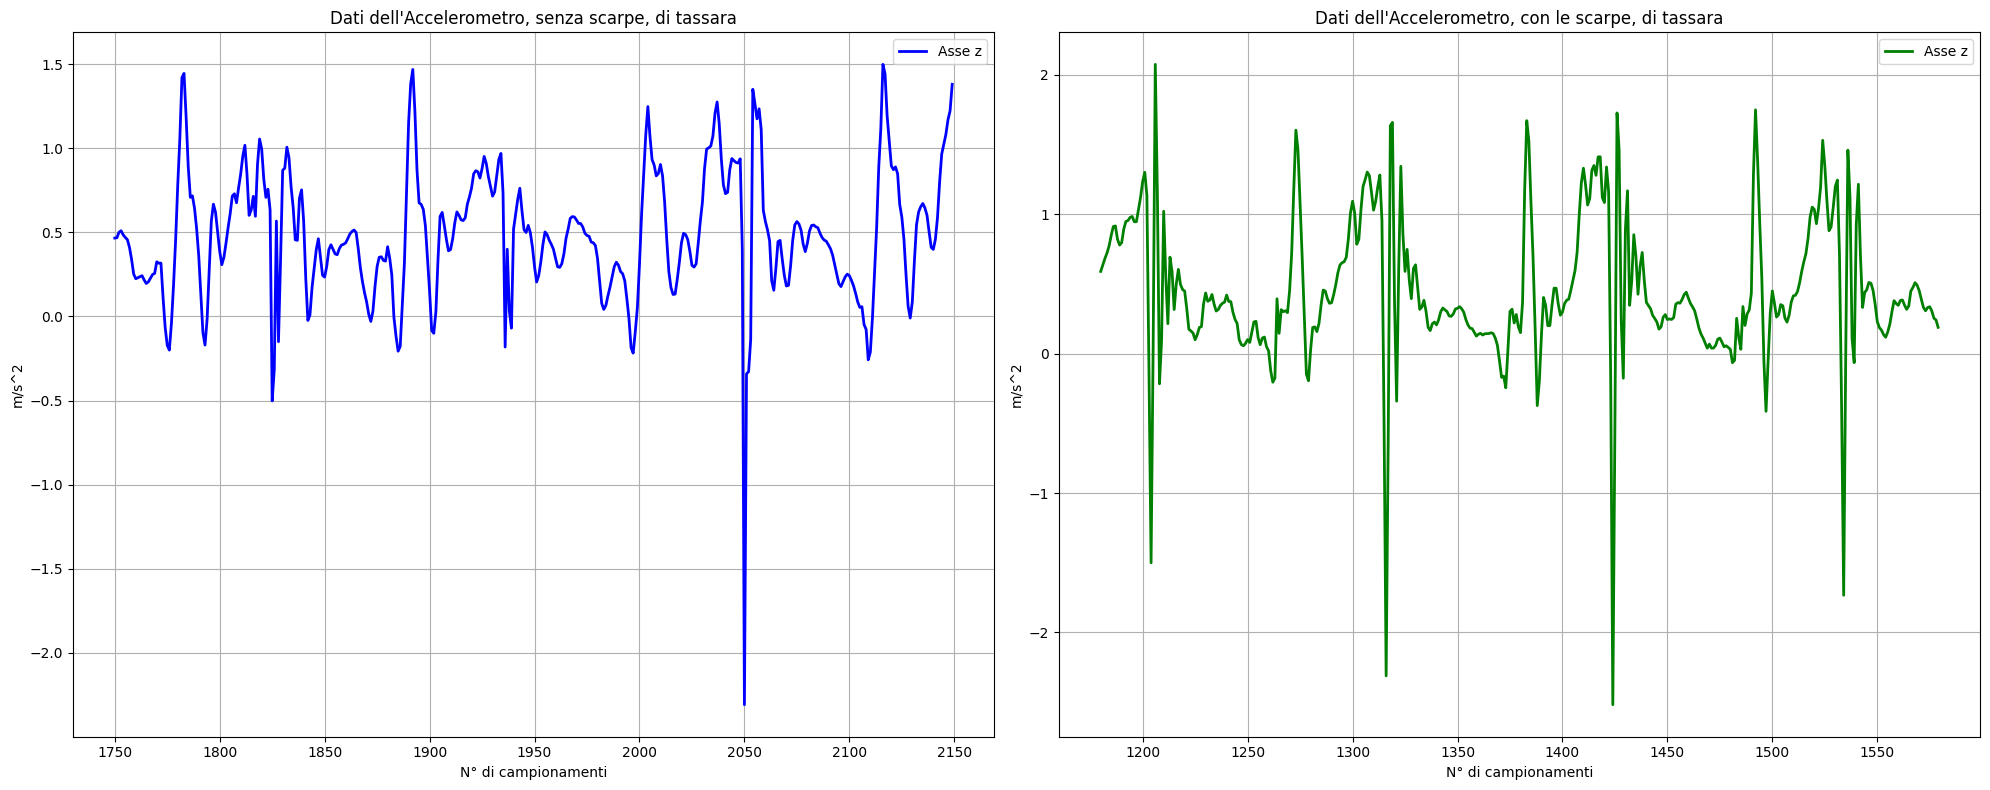

In [87]:
plt.figure(figsize=(20,8))
plt.subplot(1, 2, 1)
plt.plot(Accelerometro[0][8]["z"][200:600], 'b', label="Asse z",linewidth=2)
plt.title("Dati dell'Accelerometro, senza scarpe, di " + nomi[8])
plt.xlabel("N° di campionamenti")
plt.ylabel("m/s^2")
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Accelerometro[1][8]["z"][200:600], 'g', label="Asse z",linewidth=2)
plt.title("Dati dell'Accelerometro, con le scarpe, di " + nomi[8])
plt.xlabel("N° di campionamenti")
plt.ylabel("m/s^2")
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()


In questa prima esplorazione dei dati è stato preso in esame l'asse "z" dell'accelerometro. A seconda del posizionamento dello strumento, i valori possono assumere significati diversi: nel momento della misura, un valore positivo indica un’accelerazione in avanti, mentre un valore negativo rappresenta un’accelerazione all’indietro.

#### Cosa si nota?
1. Si può notare subito che la camminata sembrerebbe più rigida. Inoltre è evidente che l'accelerazione negativa risulta avere picchi molto più forti.
2. Inoltre si nota il ripetersi di un pattern, in modo più chiaro, quando si usano le scarpe da calcio.

### Seconda stampa (dati grezzi)

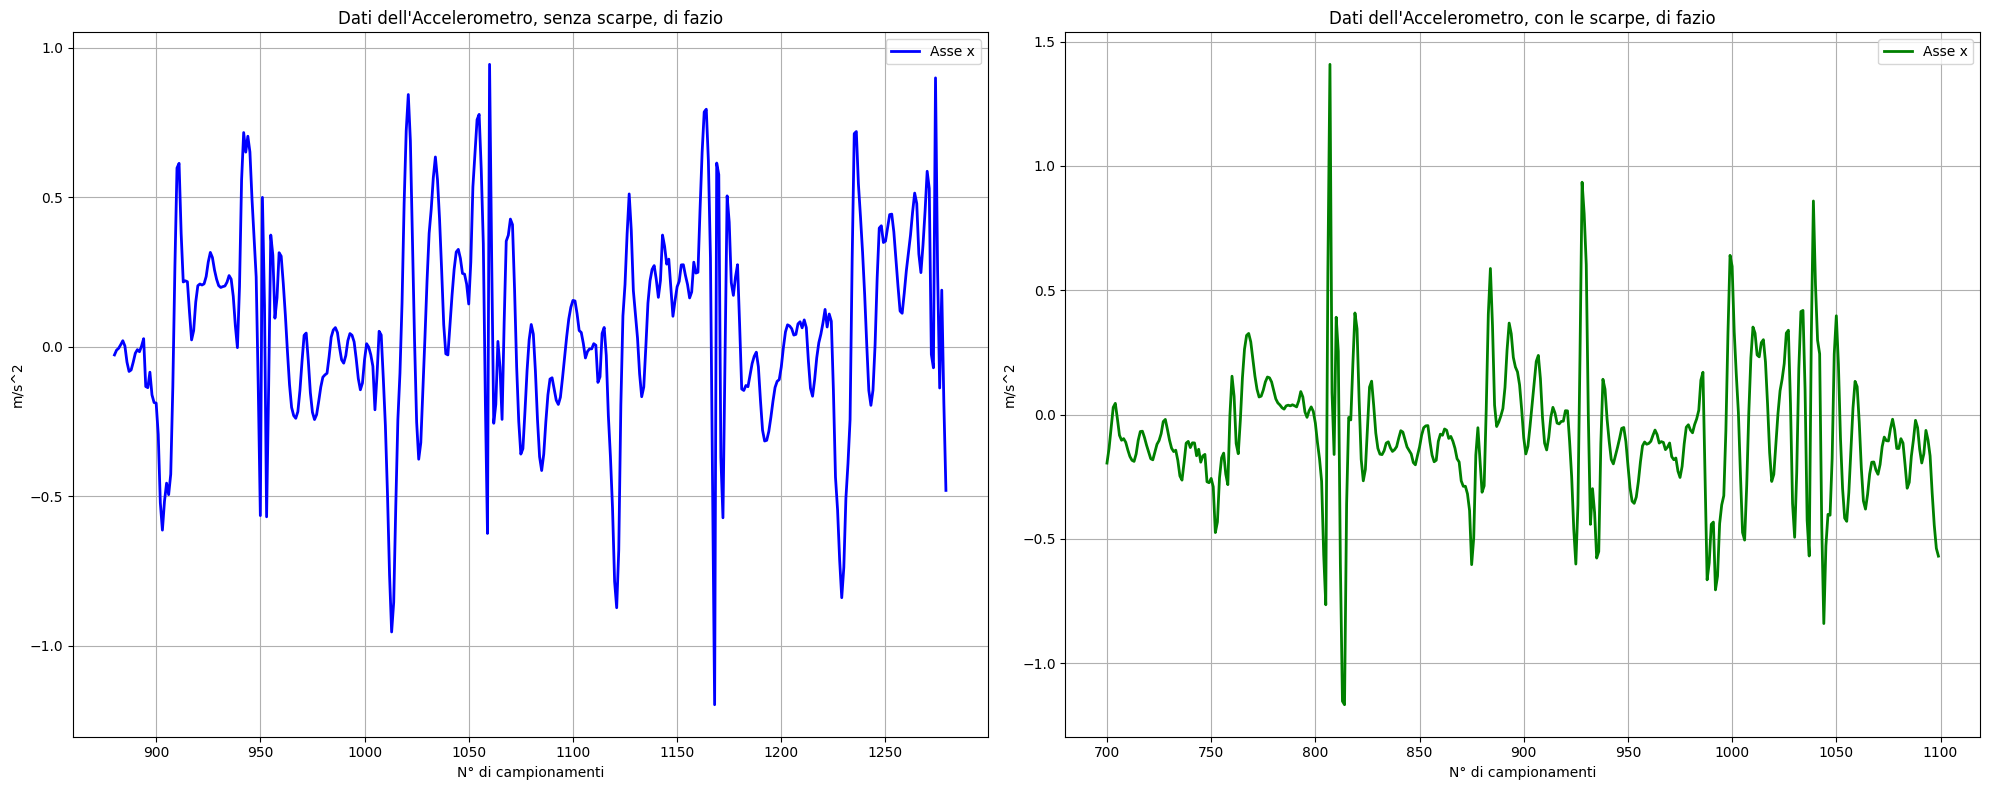

In [88]:
plt.figure(figsize=(20,8))
plt.subplot(1, 2, 1)
plt.plot(Accelerometro[0][2]["x"][200:600], 'b', label="Asse x",linewidth=2)
plt.title("Dati dell'Accelerometro, senza scarpe, di " + nomi[2])
plt.xlabel("N° di campionamenti")
plt.ylabel("m/s^2")
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Accelerometro[1][2]["x"][200:600], 'g', label="Asse x",linewidth=2)
plt.title("Dati dell'Accelerometro, con le scarpe, di " + nomi[2])
plt.xlabel("N° di campionamenti")
plt.ylabel("m/s^2")
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

In questa visualizzazione si osserva l'asse "x" dell'accelerometro. Una misura positiva, da parte dello stumento, indica un'accelerazione verso l'interno del piede al contrario, una negativa, indica un'accelerazione verso l'esterno.

#### Cosa si nota?
1. Il segnale raccolto con le scarpe risulta, mediamente, negativo rispetto a quello raccolto da scalzi che è positivo. 
2. Inoltre i picchi positivi maggiori di 0.5 m/s^2 (accelerazione verso l'interno) sono più frequenti quando si cammina scalzi.
3. I picchi registrati con le scarpe, presentano una maggiore ripidità rispetto a quelli registrati senza scarpe.

### Terza stampa (dati grezzi)

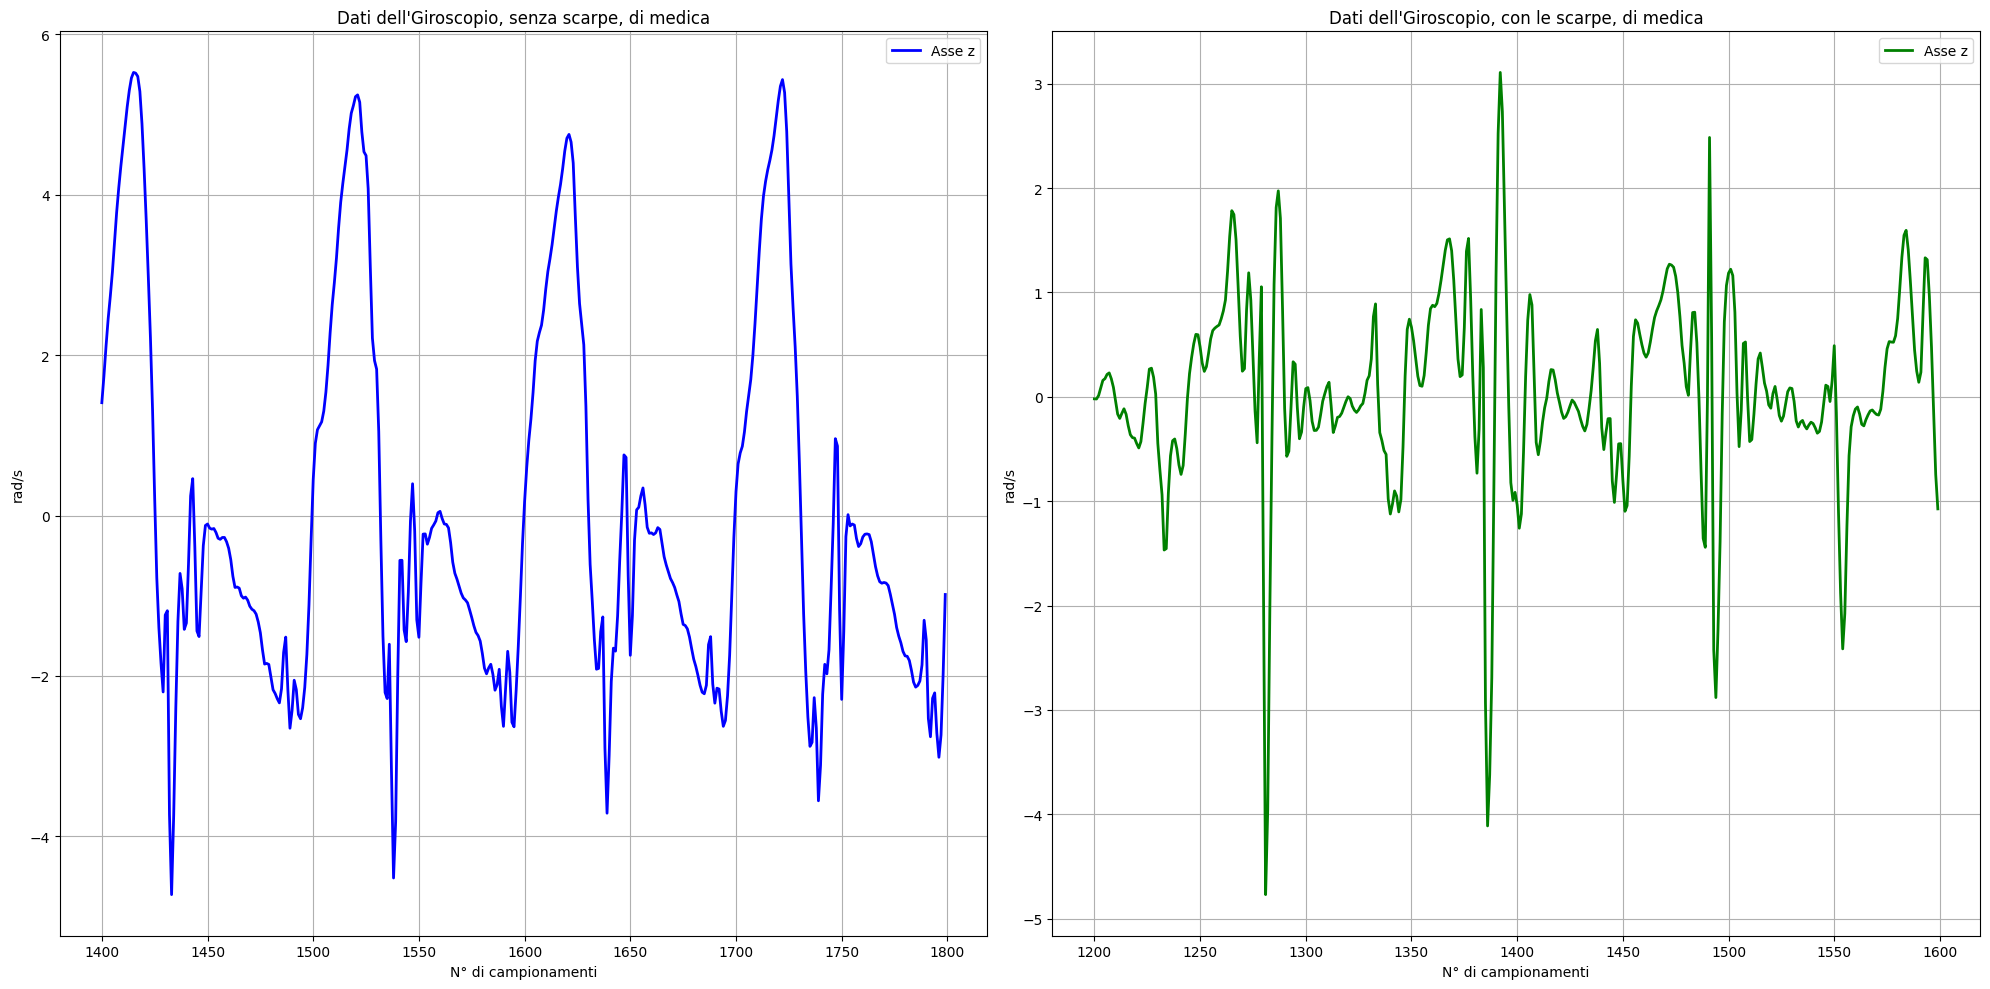

In [89]:
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.plot(Giroscopio[0][6]["z"][200:600], 'b', label="Asse z",linewidth=2)
plt.title("Dati dell'Giroscopio, senza scarpe, di " + nomi[6])
plt.xlabel("N° di campionamenti")
plt.ylabel("rad/s")
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Giroscopio[1][6]["z"][200:600], 'g', label="Asse z",linewidth=2)
plt.title("Dati dell'Giroscopio, con le scarpe, di " + nomi[6])
plt.xlabel("N° di campionamenti")
plt.ylabel("rad/s")
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

In questa visualizzazione, l'asse preso in esame è "z". Tuttavia questa volta i dati sono raccolti dal Giroscopio. Tale strumento permette di misurare le rotazioni effettuate. Al momento della misura: una rotazione positiva indica una ratazione verso l'esterno, mentre un valore negativo evidenzia una rotazione interna.

#### Cosa si nota?
1. La prima cosa che salta all'occhio sono le dimensioni dei picchi. infatti, nelle misurazioni senza scarpe si nota che la rotazione è meno violenta.
2. Come seconda osservazione si possono notare i valori registrati. Infatti con le scarpe si ha una rotazione verso l'esterno limitata.

## Fase di filtraggio
In questa sezione verranno applicati dei __filtri__ ai diversi __segnali__.     
Il filtraggio ha __l’obiettivo__ di __ridurre il rumore__ e migliorare la qualità del dato, rendendo __l’andamento__ più __regolare__ e interpretabile.         
La scelta di un buon filtro è fondamentale in quanto poi influirà sull'analisi del dato.      
Saranno usati __filtri gaussiani__ e di __Savitzky–Golay__ rispettivamente per giroscopio e accelerometro.


In [90]:
sigme = 1.1, 1.1, 1.2, 1.2, 1.4, 1.3, 1.1 ,1.1, 1, 1.2, 1.1, 1, 1.1, 1.1, 1, 1.2, 1.3, 1.1, 1.1, 1.3, 1.1, 1.2, 1.5, 1.4, 1.2, 1.3, 1, 1.2, 1.4, 1.4, 1.2, 1.3, 1, 1.2, 1.5, 1.4, 1.3, 1.4, 1.2, 1.3, 1.6, 1.4, 1.1, 1.4, 1, 1.2, 1.5, 1.1, 1.1, 1.2, 1.2, 1.1, 1.3, 1.1, 1.1, 1.1, 1, 1.1, 1.3, 1.1
assi = "x", "y", "z"

In [91]:
import numpy as np
from scipy.ndimage import gaussian_filter
from scipy.signal import savgol_filter


j=0
for i in range(size2):
    for asse in assi:
        Accelerometro[0][i][asse] = savgol_filter(Accelerometro[0][i][asse], window_length=11, polyorder=3)
        #print("applico sigma: ", sigme[j], " per asse: ", asse, " per soggetto: ", nomi[i], "scalzo")
        #Accelerometro[0][i][asse] = gaussian_filter(Accelerometro[0][i][asse], sigma=sigme[j])
        j += 1
    for asse in assi:
        Accelerometro[1][i][asse] = savgol_filter(Accelerometro[1][i][asse], window_length=11, polyorder=3)
        #print("applico sigma: ", sigme[j], " per asse: ", asse, " per soggetto: ", nomi[i], "con scarpe")
        #Accelerometro[1][i][asse] = gaussian_filter(Accelerometro[1][i][asse], sigma=sigme[j])
        j += 1
    
j=0
for i in range(size2):
    for asse in assi:
        #print("applico sigma: ", sigme[j], " per asse: ", asse, " per soggetto: ", nomi[i], "scalzo")
        Giroscopio[0][i][asse] = gaussian_filter(Giroscopio[0][i][asse], sigma=sigme[j])
        j += 1
    for asse in assi:
        #print("applico sigma: ", sigme[j], " per asse: ", asse, " per soggetto: ", nomi[i], "con scarpe")
        Giroscopio[1][i][asse] = gaussian_filter(Giroscopio[1][i][asse], sigma=sigme[j])
        j += 1


## Estrazione caratteristiche dai segnali

In questa sezione, verranno __evidenziate__ alcune __caratteristiche__ dei diversi segnali.     
Naturalmente, dopo l'estrazione di tali caratteristiche, saranno visualizzate  in modo appropriato. L'__obiettivo__ sarà quello di: notare __clusterizzazione__ tra __soggetti__ e, successiavamente, __evidenziare__ le __differenze__ dei segnali raccolti __senza scarpe__ e __con le scarpe__ da calcio.

### Funzione usata per estrarre le caratteristiche
La funzione definita di seguito permette di estrarre: __Deviazione standard__, __Energia totale__ (somma dei quadrati di ogni valore), __Frequenza dominante__, __Valore massimo__, __Valore medio__ ed __Escursione__ (val_Max - val_min).

In [92]:
import numpy as np

def estrai_caratteristiche(seg):
    # Deviazione standard
    std = np.std(seg)
    # Energia totale
    energia = np.sum(seg**2)
# Frequenza dominante
    seg2 = seg - np.mean(seg)
    N = len(seg2) # numero di campioni
    freqs = np.fft.rfftfreq(N, d=1/100) # asse delle frequenze positive
    fft_vals = np.fft.rfft(seg2) # FFT del segnale
    potenza = np.abs(fft_vals)**2 # spettro di potenza
    # indice del picco massimo
    idx_max = np.argmax(potenza)
    freq_dominante = freqs[idx_max] # frequenza dominante
#
    # Valore massimo
    max_val = np.max(seg)
    # Media
    val_medio = np.mean(seg)
    # Escursione del segnale
    escursione = np.ptp(seg)
    
    return std, freq_dominante, max_val, val_medio, escursione

### Fase di estrazione
Di seguito si provvede ad estrarre caratteristiche rilevanti dai segnali

In [93]:

# Esempio: estrai per tutti i soggetti, asse 'x'
caratteristiche_acc = []
caratteristiche_gyr = []

for i in range(size2):
    # Accelerometro senza scarpe
    std, freq_dom, max_val, val_medio, escursione = estrai_caratteristiche(Accelerometro[0][i]['x'])
    caratteristiche_acc.append([std, freq_dom, max_val, val_medio, escursione])
    # Giroscopio senza scarpe
    std, freq_dom, max_val, val_medio, escursione = estrai_caratteristiche(Giroscopio[0][i]['z'])
    caratteristiche_gyr.append([std, freq_dom, max_val, val_medio, escursione])


for i in range(size2):
    # Accelerometro con scarpe
    std, freq_dom, max_val, val_medio, escursione = estrai_caratteristiche(Accelerometro[1][i]['x'])
    caratteristiche_acc.append([std, freq_dom, max_val, val_medio, escursione])
    # Giroscopio con scarpe
    std, freq_dom, max_val, val_medio, escursione = estrai_caratteristiche(Giroscopio[1][i]['z'])
    caratteristiche_gyr.append([std, freq_dom, max_val, val_medio, escursione])

# Ora puoi plottare le caratteristiche con uno scatter plot
caratteristiche_acc = np.array(caratteristiche_acc)
caratteristiche_gyr = np.array(caratteristiche_gyr)

### Prima stampa
Qui l'attenzione sarà posta alla clusterizzazione di soggetti.

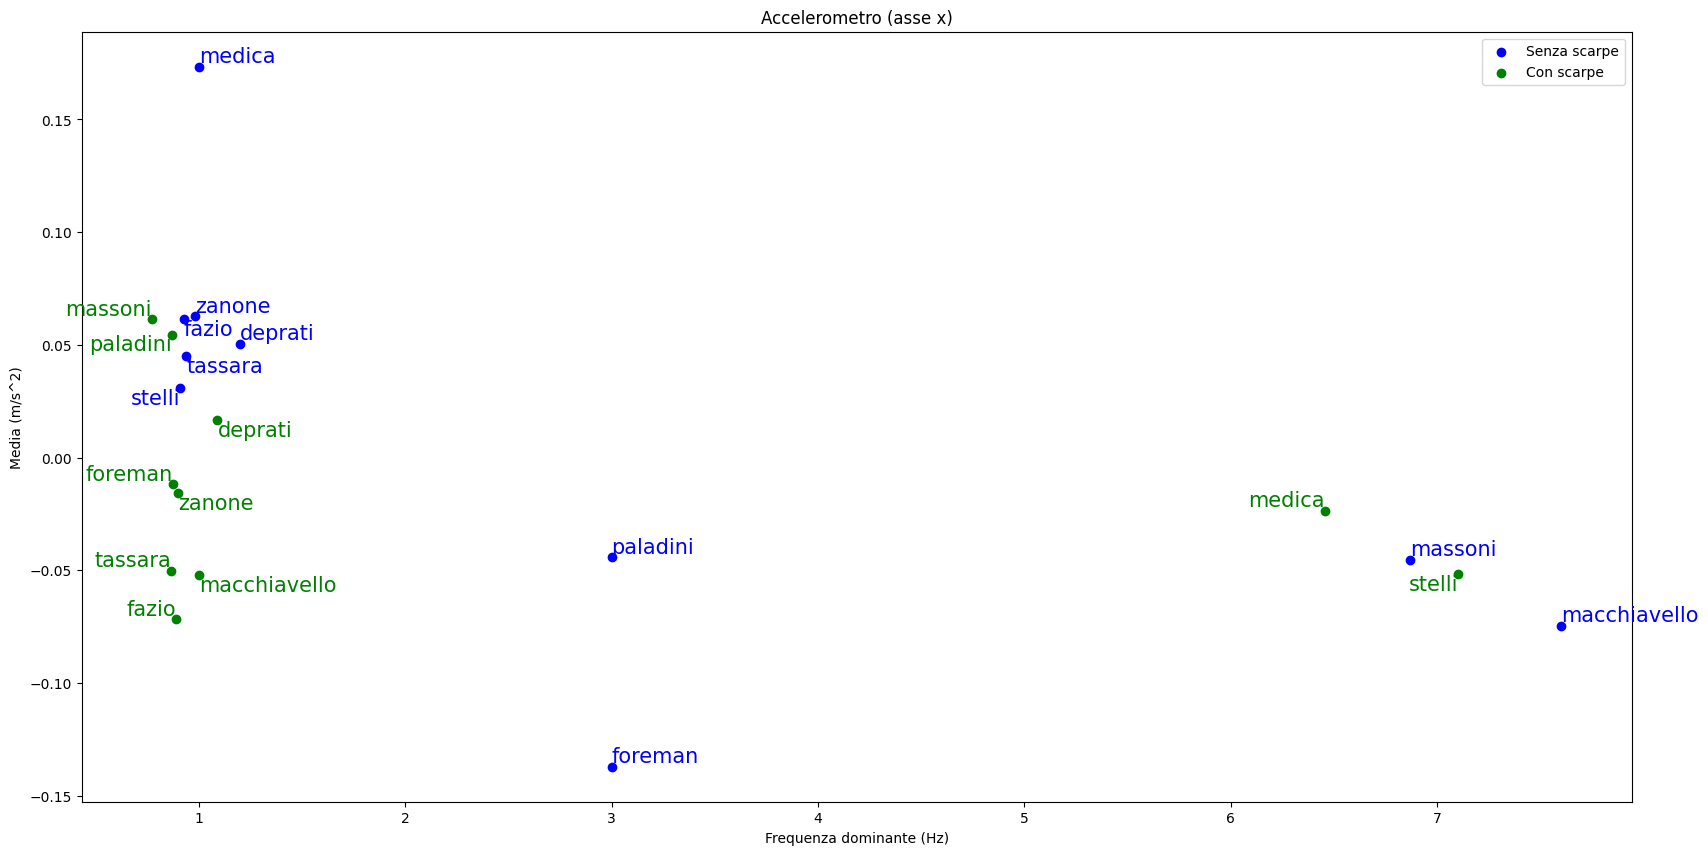

In [94]:
asse_x = 1 # Frequenza dominante
asse_y = 3 # Media

plt.figure(figsize=(20,10))
plt.scatter(caratteristiche_acc[:size2,asse_x], caratteristiche_acc[:size2,asse_y], color='blue')
plt.scatter(caratteristiche_acc[size2:,asse_x], caratteristiche_acc[size2:,asse_y], color='green')

# Aggiungi i nomi accanto ai punti
for i, nome in enumerate(nomi):
    if nome == "stelli":
        plt.text(caratteristiche_acc[i,asse_x], caratteristiche_acc[i,asse_y], nome, fontsize=15, ha='right', va='top', color='blue')
    elif nome == "tassara":
        plt.text(caratteristiche_acc[i,asse_x], caratteristiche_acc[i,asse_y], nome, fontsize=15, ha='left', va='top', color='blue')
    elif nome == "fazio":
        plt.text(caratteristiche_acc[i,asse_x], caratteristiche_acc[i,asse_y], nome, fontsize=15, ha='left', va='top', color='blue')
    else:
        plt.text(caratteristiche_acc[i,asse_x], caratteristiche_acc[i,asse_y], nome, fontsize=15, ha='left', va='bottom', color='blue')

for i, nome in enumerate(nomi):
    if nome == "macchiavello":
        plt.text(caratteristiche_acc[i+size2,asse_x], caratteristiche_acc[i+size2,asse_y], nome, fontsize=15, ha='left', va='top', color='green')
    elif nome == "zanone":
        plt.text(caratteristiche_acc[i+size2,asse_x], caratteristiche_acc[i+size2,asse_y], nome, fontsize=15, ha='left', va='top', color='green')
    elif nome == "stelli":
        plt.text(caratteristiche_acc[i+size2,asse_x], caratteristiche_acc[i+size2,asse_y], nome, fontsize=15, ha='right', va='top', color='green')
    elif nome == "deprati":
        plt.text(caratteristiche_acc[i+size2,asse_x], caratteristiche_acc[i+size2,asse_y], nome, fontsize=15, ha='left', va='top', color='green')
    elif nome == "paladini":
        plt.text(caratteristiche_acc[i+size2,asse_x], caratteristiche_acc[i+size2,asse_y], nome, fontsize=15, ha='right', va='top', color='green')
    else:
        plt.text(caratteristiche_acc[i+size2,asse_x], caratteristiche_acc[i+size2,asse_y], nome, fontsize=15, ha='right', va='bottom', color='green')

plt.xlabel('Frequenza dominante (Hz)')
plt.ylabel('Media (m/s^2)')
plt.title('Accelerometro (asse x)')
plt.legend(['Senza scarpe', 'Con scarpe'])
plt.show()

#### Osservazioni
1. Si nota come, la maggior parte dei segnali presenta una Frequenza dominante 1Hz. Tale frequenza è associata ad una normale camminata umana.
2. __paladini__ e __foreman__, scalzi, hanno frequenza di 3Hz che di solito è associata ad una cammianta molto veloce o corsetta.
3. __medica__ passa da una frequenza dominante normale, 1Hz, ad una anormale, 6.5Hz. Una probabile spiegazione è che, nel segnale acquisito con le scarpe, la frequenza dominante è data dall’impatto dei tacchetti con il terreno.
4. __deprati__ , __tassara__, __fazio__ e __zanone__ presentano un cambio nella media del segnale che, di fatto, diventa negativa.
5. __deprati__ risulta avere una variazione dei valori minore rispetto a tutti gli altri segnali.
6. Le scarpe da calcio per 8 soggetti sembrano normalizzare il passo.

### Seconda stampa
Ora l'attenzione, sarà posta sulla differenza tra i segnali raccolti: usando le scarpe e quelli senza.

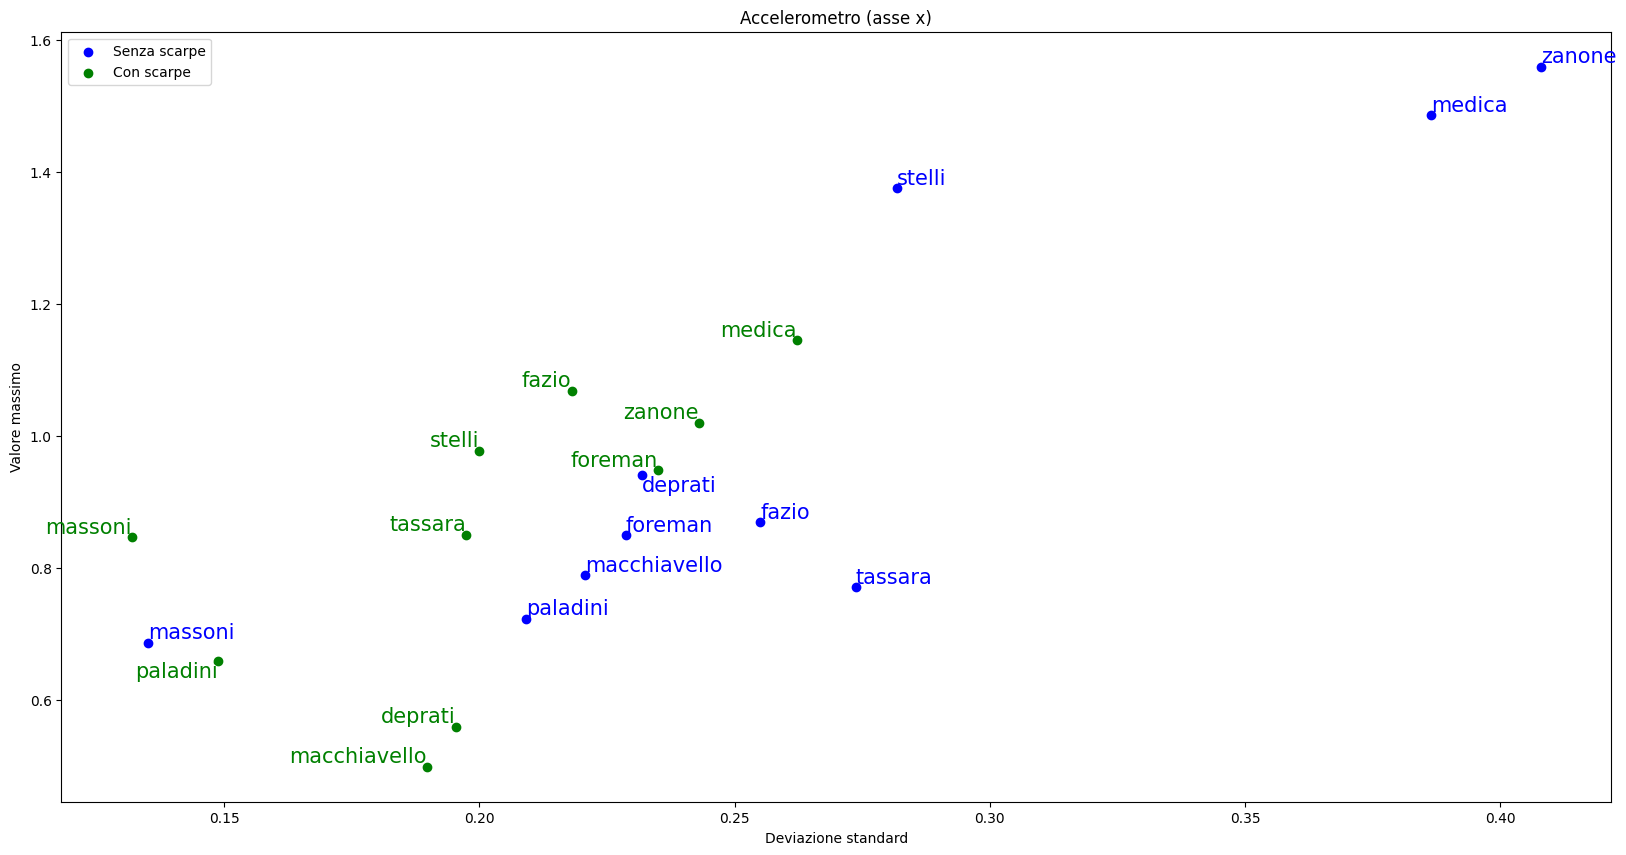

In [95]:
asse_x = 0 # Deviazione standard
asse_y = 2 # Valore massimo

plt.figure(figsize=(20,10))
plt.scatter(caratteristiche_acc[:size2,asse_x], caratteristiche_acc[:size2,asse_y], color='blue')
plt.scatter(caratteristiche_acc[size2:,asse_x], caratteristiche_acc[size2:,asse_y], color='green')

# Aggiungi i nomi accanto ai punti
for i, nome in enumerate(nomi):
    if nome == "deprati":
        plt.text(caratteristiche_acc[i,asse_x], caratteristiche_acc[i,asse_y], nome, fontsize=15, ha='left', va='top', color='blue')
    else:
        plt.text(caratteristiche_acc[i,asse_x], caratteristiche_acc[i,asse_y], nome, fontsize=15, ha='left', va='bottom', color='blue')

for i, nome in enumerate(nomi):
    if nome == "paladini":
        plt.text(caratteristiche_acc[i+size2,asse_x], caratteristiche_acc[i+size2,asse_y], nome, fontsize=15, ha='right', va='top', color='green')
    else:
        plt.text(caratteristiche_acc[i+size2,asse_x], caratteristiche_acc[i+size2,asse_y], nome, fontsize=15, ha='right', va='bottom', color='green')

plt.xlabel('Deviazione standard')
plt.ylabel('Valore massimo')
plt.title('Accelerometro (asse x)')
plt.legend(['Senza scarpe', 'Con scarpe'])
plt.show()

### Osservazioni
1. Sembrerebbe esserci una sorta di divisione tra i segnali raccolti, con le scarpe da calcio e scalzi. __massoni__ risulta essere un outlier. Infatti, la sua camminata, da scalzo, è molto simile ad quella con le scarpe da calcio.
2. Si nota come, a parte per __foreman__ e __massoni__, la deviazione standard diminuisce quando si usano le scarpe da calcio. Naturalmente la scarpa, da calcio, limita il movimento che il piede può effettuare rispetto a quando è scalzo.

### Terza stampa
Questa visualizzazione usa i dati del giroscopio

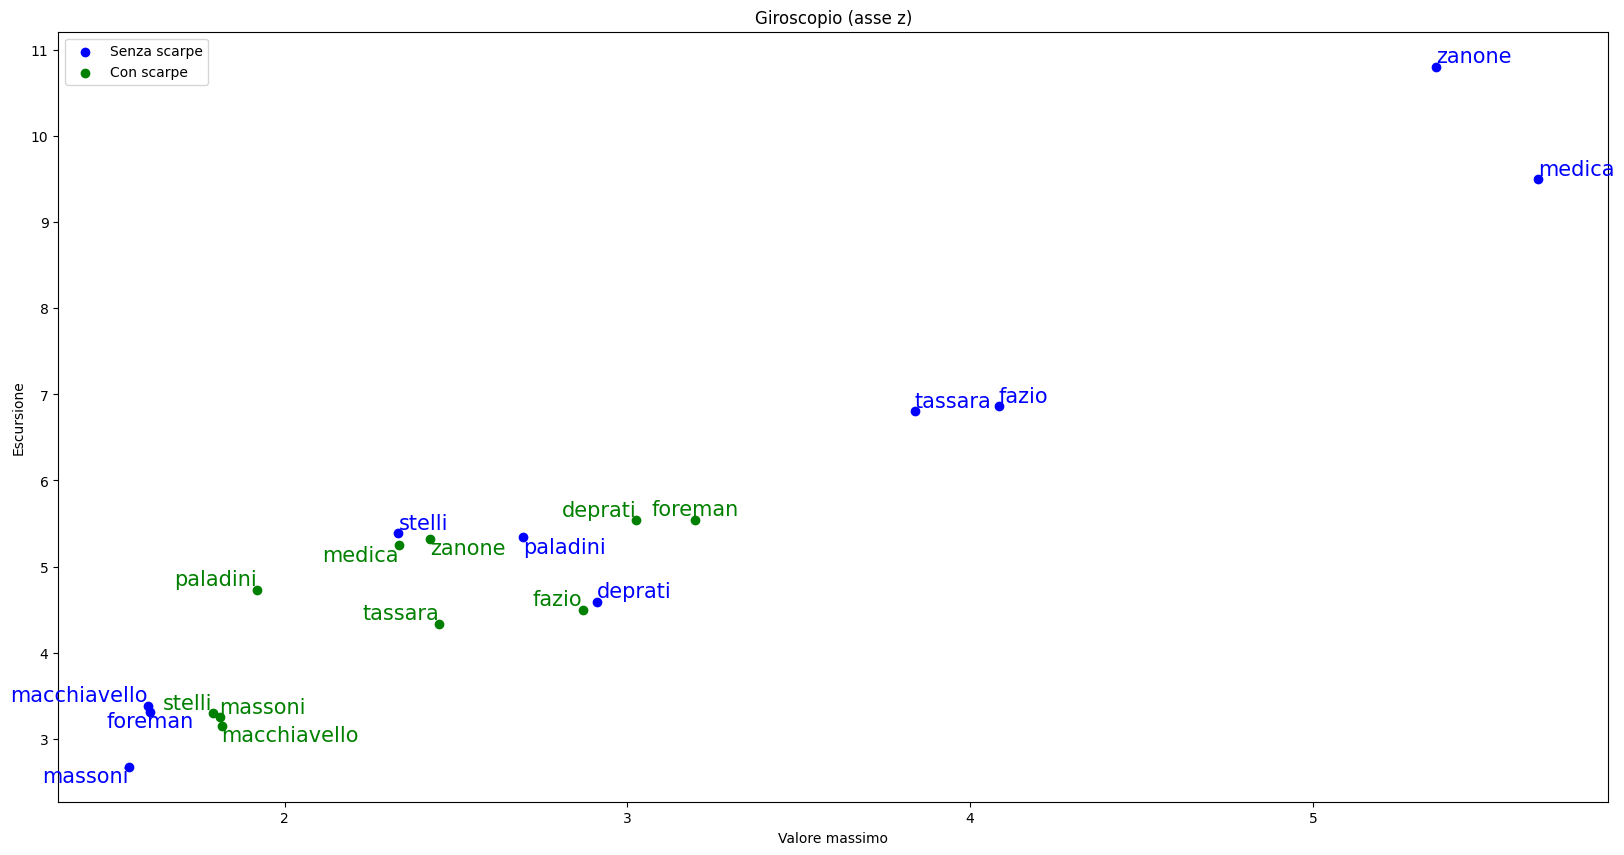

In [96]:
# std, freq_dominante, max_val, val_medio, escursione
asse_x = 2 # max_val
asse_y = 4 # escursione

plt.figure(figsize=(20,10))
plt.scatter(caratteristiche_gyr[:size2, asse_x], caratteristiche_gyr[:size2, asse_y], color='blue')
plt.scatter(caratteristiche_gyr[size2:, asse_x], caratteristiche_gyr[size2:, asse_y], color='green')

# Aggiungi i nomi accanto ai punti
for i, nome in enumerate(nomi):
    if nome == "foreman":
        plt.text(caratteristiche_gyr[i, asse_x], caratteristiche_gyr[i, asse_y], nome, fontsize=15, ha='center', va='top', color='blue')
    elif nome == "massoni":
        plt.text(caratteristiche_gyr[i, asse_x], caratteristiche_gyr[i, asse_y], nome, fontsize=15, ha='right', va='top', color='blue')
    elif nome == "macchiavello":
        plt.text(caratteristiche_gyr[i, asse_x], caratteristiche_gyr[i, asse_y], nome, fontsize=15, ha='right', va='bottom', color='blue')
    elif nome == "paladini":
        plt.text(caratteristiche_gyr[i, asse_x], caratteristiche_gyr[i, asse_y], nome, fontsize=15, ha='left', va='top', color='blue')
    else:
        plt.text(caratteristiche_gyr[i, asse_x], caratteristiche_gyr[i, asse_y], nome, fontsize=15, ha='left', va='bottom', color='blue')

for i, nome in enumerate(nomi):
    if nome == "macchiavello":
        plt.text(caratteristiche_gyr[i+size2, asse_x], caratteristiche_gyr[i+size2, asse_y], nome, fontsize=15, ha='left', va='top', color='green')
    elif nome == "massoni":
        plt.text(caratteristiche_gyr[i+size2, asse_x], caratteristiche_gyr[i+size2, asse_y], nome, fontsize=15, ha='left', va='bottom', color='green')
    elif nome == "foreman":
        plt.text(caratteristiche_gyr[i+size2, asse_x], caratteristiche_gyr[i+size2, asse_y], nome, fontsize=15, ha='center', va='bottom', color='green')
    elif nome == "zanone":
        plt.text(caratteristiche_gyr[i+size2, asse_x], caratteristiche_gyr[i+size2, asse_y], nome, fontsize=15, ha='left', va='top', color='green')
    elif nome == "medica":
        plt.text(caratteristiche_gyr[i+size2, asse_x], caratteristiche_gyr[i+size2, asse_y], nome, fontsize=15, ha='right', va='top', color='green')
    else:
        plt.text(caratteristiche_gyr[i+size2, asse_x], caratteristiche_gyr[i+size2, asse_y], nome, fontsize=15, ha='right', va='bottom', color='green')

plt.xlabel('Valore massimo')
plt.ylabel('Escursione')
plt.title('Giroscopio (asse z)')
plt.legend(['Senza scarpe', 'Con scarpe'])
plt.show()

#### Osservazioni
1. Si può notare subito che l'escursione, da scalzi, può presentare picchi notevoli. Infatti sia __tassara__ che __fazio__, che sono sempre stati nella media, presentano valori leggermente anomali.
2. Anche in questo caso, sembrerebbe che le scarpe da calcio riescano a limitare i valori. Questa apparente limitazione si applica ad entrambe le caratteristiche. Il che vuol dire, per certi versi, che le scarpe normalizzano la camminata.
3. __medica__ e __zanone__ quando indossano le scarpe da calcio producono valori quasi nella media.

## Conclusione
In sintesi, l'analisi ha confermato che l’utilizzo delle scarpe da calcio modifica la camminata rendendola più rigida, con conseguenti variazioni nei segnali raccolti dall'accelerometro e dal giroscopio. In particolare, si è osservata una maggior costrizione nei movimenti, dal momento che si indossano le scarpe da calcio.      
Questo conferma che le scarpe da calcio modificano la biomeccanica del passo.    
Tuttavia lo studio è limitato ad: un numero contenuto di soggetti e condizioni normali degli esperimenti. Inoltre è stato messo sotto esame, solamente, come varia il passo durante una camminata leggera su piano rigido.      
In ogni caso lo studio sembra confermare l'ipotesi: «l’uso delle scarpe da calcio rende il passo più rigido, con un andamento meno naturale e più rigido e robotico».        
Tale manifestazione la si nota attraverso:       
1. Accelerometro: si osservano picchi più marcati lungo l'asse verticale (y) e variazioni per quanto riguarda la media del segnale. In alcuni casi, la media cambia proprio il segno, il che può essere indice di una variazione nella distribuzione del peso.
La frequenza dominante tra tutti i segnali rimane circa 1Hz (normale passo umano) tuttavia, per alcuni, le frequenze dominanti sono maggiori di 6Hz.        
2. Giroscopio: si osserva una maggiore varietà nelle misure quando il soggetto non indossa le scarpe. Inoltre i picchi del segnale risultano decisamente meno ripidi. Al contrario, quando si usano le scarpe, oltre ad avere picchi più ripidi il pattern della camminata risulta più riconoscibile.        

Un'osservazione inaspettata è la tendenza, quando si usano le scarpe, alla normalizzazione. Infatti, nonostante rendano il passo più robotico e  rigido, riducono la variabilità delle caratteristiche dei segnali.        


In conclusione, i risultati sembrano confermare che, la presenza dei tacchetti e la struttura rigida delle scarpe, influenzino la biomeccanica della camminata. È vero che normalizzano la camminata ma, modificano la naturalezza del passo rendendolo più rigido e costringendo il piede in certi movimenti.
Questo lo rende più innaturale.

## Ringraziamenti
Un speciale ringraziamento va alla società sportiva ASD Vecchio Castagna Quarto. 
Soprattutto ci tengo a ringraziare in modo speciale i ragazzi: Stelli Lorenzo, Deprati Gabriele, Fazio Gabriele, Foreman Riccardo, Macchiavello Paride, Massoni Umberto, Medica Christian, Paladini Alessandro, Tassara Marco e Zanone Alessandro che hanno reso possibile lo studio partecipato con entusiasmo.